In [235]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [236]:
data = load_wine()

# TASK 1:Exploratory Data Analysis

In [237]:
df = pd.DataFrame(data.data, columns=data.feature_names)
#data.data[:5] #prints only numbers
df.head()#first 5 rows. More readable

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [238]:
#df["target"] = data.target
df_y = pd.DataFrame(data.target, columns=["target"])
df_y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [239]:
df.describe() #gives a summary of the data. min, max, mean, standard deviation, 25 50 and 75 percentiles

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [240]:
import seaborn as sns

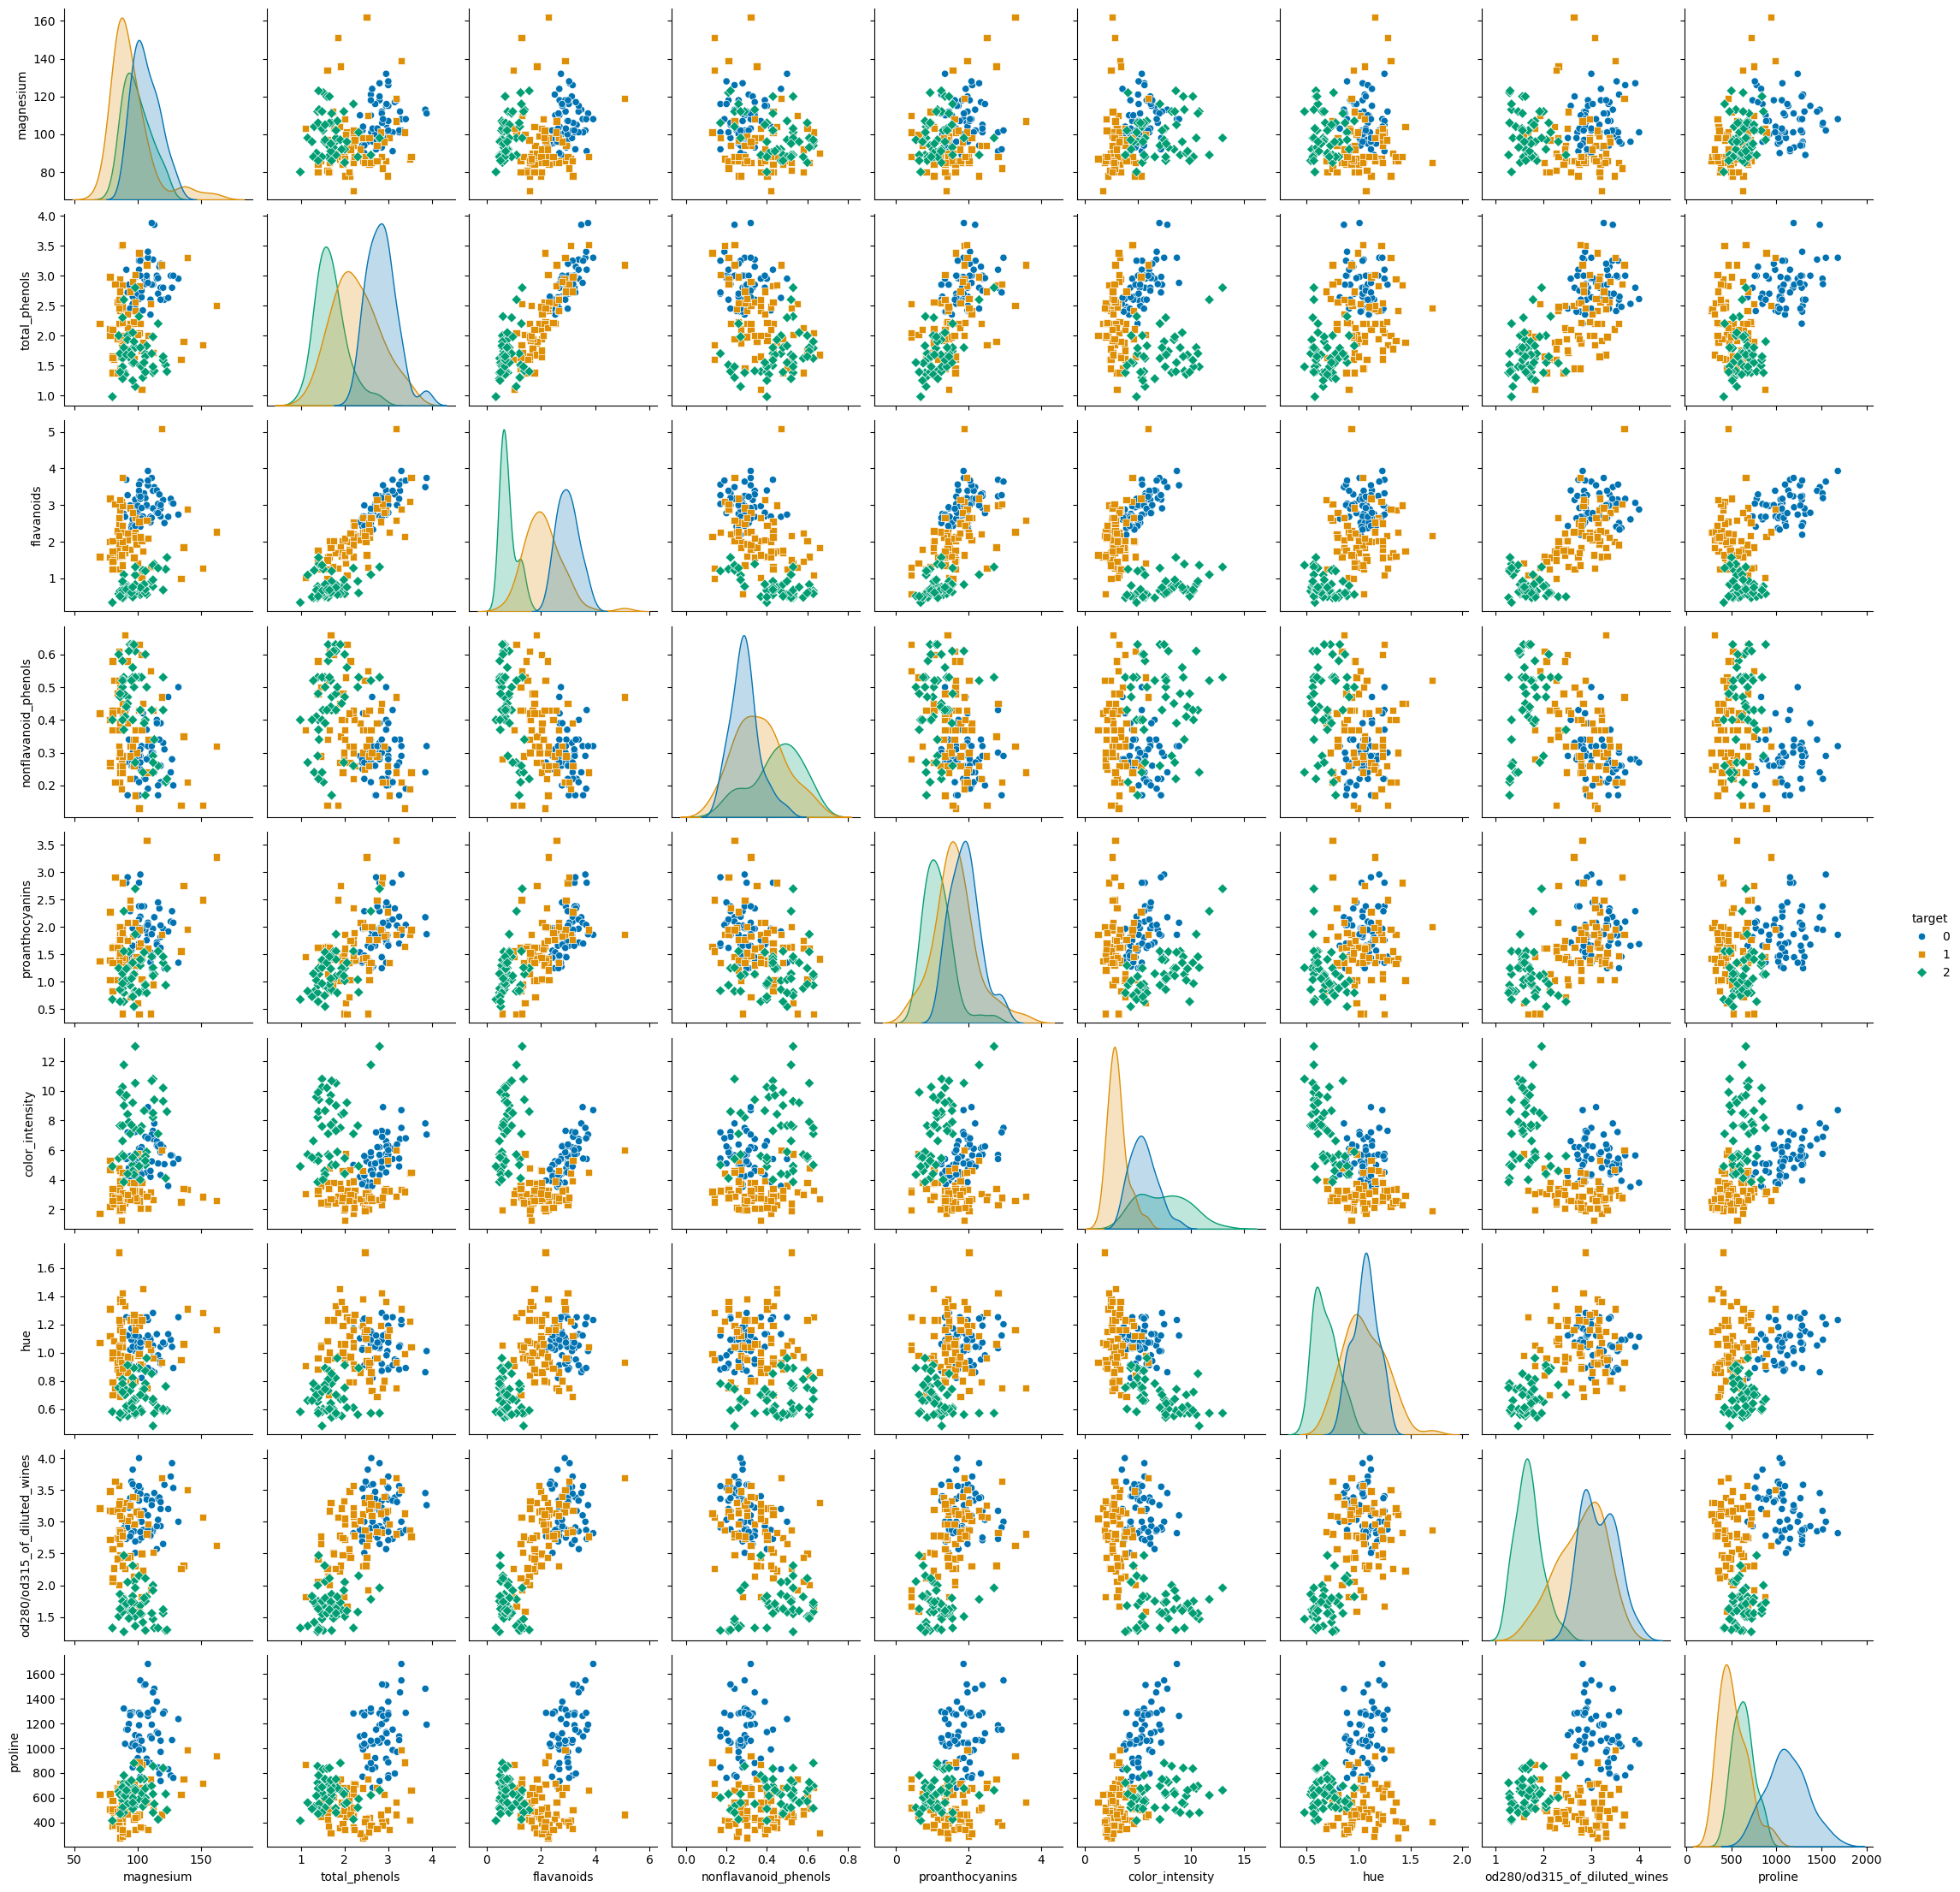

In [241]:
# Merge df (features) and df_y (target) into one DataFrame
df_combined = pd.concat([df.iloc[:, 4:], df_y], axis=1)
markers = ["o", "s", "D"]  # "o" = circle, "s" = square, "D" = diamond ***color is better but I put it anyway
sns.pairplot(df_combined, hue="target", palette="colorblind",markers=markers)

plt.show()

# Task 2: Implement Decision Tree

In [242]:
df.shape[1]

13

In [243]:
class DecisionTree:
    def __init__(self,max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
        self.internal_node_count=0
    def calc_gini_index(self,y):
        _,counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    def calc_gini_node(self,left_y, right_y,y):
        left_gini = self.calc_gini_index(left_y)
        right_gini = self.calc_gini_index(right_y)
        return (len(left_y) * left_gini + len(right_y) * right_gini) / len(y)
    def split_node(self, X, y):
        best_score = float("inf")
        data_split = None
        index = None
        value = None
        for feature_index in range(X.shape[1]):
            for val in np.unique(X[:, feature_index]):
                left_data = X[X[:, feature_index] <= val]
                right_data = X[X[:, feature_index] > val]
                score = self.calc_gini_node(left_data, right_data, y)
                if score < best_score:
                    best_score = score
                    data_split = (left_data, right_data)
                    index = feature_index
                    value = val
        return {"split":data_split, "feature index": index, "split value": value}
    def fit(self, X, y):
        self.tree = self.build_tree(X, y)
        return None
    def build_tree(self, X, y, depth=0):
        if len(np.unique(y)) == 1: #check if all target values are the same, no splits necessary
            return y[0]
        if self.max_depth is not None and depth >= self.max_depth: #check if max depth is reached
            return np.bincount(y).argmax() #returns the most common target value
        if len(y) < self.min_samples_split: #check if min samples split is reached, not enough data to split
            return np.bincount(y).argmax()
        best_split = self.split_node(X, y)
        left_data = X[X[:, best_split["feature index"]] <= best_split["split value"]]
        right_data = X[X[:, best_split["feature index"]] > best_split["split value"]]
        left_y = y[X[:, best_split["feature index"]] <= best_split["split value"]]
        right_y = y[X[:, best_split["feature index"]] > best_split["split value"]]
        self.internal_node_count+=1
        return {
            "left": self.build_tree(left_data, left_y, depth + 1),
            "right": self.build_tree(right_data, right_y, depth + 1),
            "feature_index": best_split["feature index"],
            "split_value": best_split["split value"],
            "target_value": np.bincount(y).argmax(),
            "X": X,
            "no": self.internal_node_count #no is not index, it starts from 1
        }
    def rec_predict(self, x, tree, node_checking=0):
        if isinstance(tree, np.integer):
            return tree
        if node_checking == tree["no"]:
            return tree["target_value"]
        
        if x[tree["feature_index"]] <= tree["split_value"]:
            return self.rec_predict(x, tree["left"])
        else:
            return self.rec_predict(x, tree["right"])
    def predict(self, X, node_checking=0):
        predictions = []
        for i,x in enumerate(X):
            #print(i)
            predictions.append(self.rec_predict(x, self.tree,node_checking))
        return np.array(predictions)
    
    def print_tree(self, node=None, depth=0):
        """Recursively prints the tree structure."""
        if node is None:
            node = self.tree
        if isinstance(node, dict):
            print(f"{'  ' * depth}[Feature {node['feature_index']} <= {node['split_value']}]?")
            self.print_tree(node['left'], depth + 1)
            self.print_tree(node['right'], depth + 1)
        else:
            print(f"{'  ' * depth}Class: {node}")
    def prune_tree(self, X_val, y_val):
        self.tree = self.prune(X_val, y_val, self.tree)
    def prune(self, X_val, y_val, node=None):
        """Recursively prune the tree in a post-order manner."""
        if node is None:
            node = self.tree
        if isinstance(node, dict): # this is an internal node
            node["left"] = self.prune(X_val, y_val, node['left'])
            node["right"] = self.prune(X_val, y_val, node['right'])
            accuracy= self.accuracy(X_val, y_val)
            pruned_accuracy = self.accuracy(X_val, y_val, node["no"])
            if pruned_accuracy >= accuracy:
                # If pruning improves or maintains accuracy, prune the node
                return node["target_value"]
            else:
                # Otherwise, keep the node as is
                return node
            
        else: #this is a leaf node
            return node
    def custom_prune_tree(self, X_val, y_val,alpha):
        self.tree = self.custom_prune(X_val, y_val, self.tree, alpha)
    def custom_prune(self, X_val, y_val, node=None, alpha=0):
        """Recursively prune the tree in a post-order manner."""
        if node is None:
            node = self.tree
        if isinstance(node, dict):
            node["left"] = self.custom_prune(X_val, y_val, node['left'], alpha)
            node["right"] = self.custom_prune(X_val, y_val, node['right'], alpha)
            accuracy= self.accuracy(X_val, y_val)
            # custom pruning logic
            Xnode = node["X"]
            f_index = node["feature_index"]
            mean = Xnode[:, f_index].mean()
            std = Xnode[:, f_index].std()
            t_n = node["split_value"]
            p_left = norm.cdf((t_n - mean) / std)
            if p_left < alpha or p_left > 1 - alpha:
                # If the probability of the split is outside the alpha range, prune
                return node["target_value"]
            else:
                # Otherwise, keep the node as is
                return node
        else: #this is a leaf node
            return node
    def accuracy(self, X, y, node_checking=0):
        predictions = self.predict(X, node_checking)
        return np.mean(predictions == y)

# Task 3: Train and Evaluate

In [244]:
from sklearn.model_selection import train_test_split

In [245]:
X_train, X_temp, y_train, y_temp = train_test_split(df,df_y, test_size=0.4, random_state=0, stratify=df_y) #60% train
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp) #20% test, 20% validation
print(X_train.shape, X_val.shape, X_test.shape)
X_train
y_train.describe()

(106, 13) (36, 13) (36, 13)


,target
count,106.000000
mean,0.943396
std,0.778646
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


In [246]:
print(y_train.value_counts(normalize=True)) #normalize=True gives the percentage of each class
print(y_val.value_counts(normalize=True)) #normalize=True gives the percentage of each class
print(y_test.value_counts(normalize=True)) #normalize=True gives the percentage of each class

target
1         0.396226
0         0.330189
2         0.273585
Name: proportion, dtype: float64
target
1         0.388889
0         0.333333
2         0.277778
Name: proportion, dtype: float64
target
1         0.416667
0         0.333333
2         0.250000
Name: proportion, dtype: float64


In [247]:
y_train.to_numpy().flatten().shape #flatten to 1D array

(106,)

In [248]:
tree = DecisionTree(min_samples_split=2)
tree.fit(X_train.to_numpy(), y_train.to_numpy().flatten())
predictions = tree.predict(X_test.to_numpy())
print(predictions[:10])

[0 1 2 0 1 0 0 1 2 2]


In [249]:
correct_predictions = np.sum(predictions == y_test.to_numpy().flatten())
total_predictions = len(y_test)
raw_test_accuracy = correct_predictions / total_predictions
print(f"Test Accuracy: {raw_test_accuracy:.2f}")
raw_val_accuracy = np.sum(tree.predict(X_val.to_numpy()) == y_val.to_numpy().flatten()) / len(y_val)
print(f"Validation Accuracy: {raw_val_accuracy:.2f}")
print(f"Acc:{tree.accuracy(X_test.to_numpy(), y_test.to_numpy().flatten()):.2f}")

Test Accuracy: 0.81
Validation Accuracy: 0.83
Acc:0.81


In [250]:
tree.print_tree()

[Feature 11 <= 2.11]?
  [Feature 10 <= 0.57]?
    Class: 2
    [Feature 7 <= 0.58]?
      [Feature 12 <= 740.0]?
        [Feature 2 <= 2.26]?
          [Feature 2 <= 2.02]?
            Class: 1
            [Feature 0 <= 12.58]?
              Class: 2
              [Feature 0 <= 12.69]?
                Class: 1
                Class: 2
          Class: 2
        [Feature 8 <= 1.3]?
          [Feature 0 <= 13.16]?
            Class: 2
            Class: 1
          Class: 2
      [Feature 6 <= 0.63]?
        Class: 2
        [Feature 0 <= 12.6]?
          Class: 2
          Class: 1
  [Feature 4 <= 86.0]?
    Class: 1
    [Feature 4 <= 88.0]?
      Class: 1
      [Feature 10 <= 1.25]?
        [Feature 7 <= 0.29]?
          [Feature 7 <= 0.27]?
            [Feature 3 <= 15.0]?
              Class: 0
              [Feature 7 <= 0.24]?
                [Feature 4 <= 106.0]?
                  [Feature 3 <= 18.0]?
                    [Feature 0 <= 13.83]?
                      [Feature 0 <= 11

# Task 4: Implement Reduced Error Pruning

In [251]:
tree.prune_tree(X_val.to_numpy(), y_val.to_numpy().flatten())
print("After pruning:")
tree.print_tree()
pruned_test_accuracy = tree.accuracy(X_test.to_numpy(), y_test.to_numpy().flatten())
print(f"Test Accuracy:{pruned_test_accuracy:.2f}")
pruned_val_accuracy = tree.accuracy(X_val.to_numpy(), y_val.to_numpy().flatten())
print(f"Validation Accuracy:{pruned_val_accuracy:.2f}")

After pruning:
[Feature 11 <= 2.11]?
  Class: 2
  [Feature 4 <= 86.0]?
    Class: 1
    [Feature 4 <= 88.0]?
      Class: 1
      [Feature 10 <= 1.25]?
        Class: 0
        [Feature 0 <= 12.21]?
          Class: 1
          Class: 0
Test Accuracy:0.78
Validation Accuracy:0.81


# Task 5: Implement Custom Pruning Method

In [ ]:
alpha_values = [0.05,0.1, 0.2]
custom_pruned_test_accuracies = []
custom_pruned_val_accuracies = []
for alpha in alpha_values:
    tree.custom_prune_tree(X_val.to_numpy(), y_val.to_numpy().flatten(), alpha)
    custom_pruned_test_accuracy = tree.accuracy(X_test.to_numpy(), y_test.to_numpy().flatten())
    custom_pruned_test_accuracies.append(custom_pruned_test_accuracy)
    print(f"Alpha: {alpha}, Custom Pruned Test Accuracy: {custom_pruned_test_accuracy:.2f}")

Alpha: 0.05, Custom Pruned Test Accuracy: 0.61
Alpha: 0.05, Custom Pruned Val Accuracy: 0.58
Alpha: 0.1, Custom Pruned Test Accuracy: 0.61
Alpha: 0.1, Custom Pruned Val Accuracy: 0.58
Alpha: 0.2, Custom Pruned Test Accuracy: 0.61
Alpha: 0.2, Custom Pruned Val Accuracy: 0.58


# Task 6: Comparison and Discussion

In [273]:
# Run all methods for different splits
unpruned_test_accuracies = []
pruned_test_accuracies = []
custom_pruned_test_accuracies = []
for random_state in range(1, 6):
    '''split data'''
    X_train, X_temp, y_train, y_temp = train_test_split(df,df_y, test_size=0.4, random_state=random_state, stratify=df_y) #60% train
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=random_state, stratify=y_temp) #20% test, 20% validation
    '''construct tree'''
    tree = DecisionTree(min_samples_split=3)
    tree.fit(X_train.to_numpy(), y_train.to_numpy().flatten())
    print(f"*****Random State: {random_state}*****")
    print()
    '''check raw accuracy'''
    print("*****Checking raw accuracy*****")
    raw_test_accuracy = tree.accuracy(X_test.to_numpy(), y_test.to_numpy().flatten())
    print(f"Test Accuracy: {raw_test_accuracy:.2f}")
    unpruned_test_accuracies.append(raw_test_accuracy)
    '''check pruned accuracy'''
    print("*****Checking pruned accuracy*****")
    tree.prune_tree(X_val.to_numpy(), y_val.to_numpy().flatten())
    pruned_test_accuracy = tree.accuracy(X_test.to_numpy(), y_test.to_numpy().flatten())
    print(f"Test Accuracy:{pruned_test_accuracy:.2f}")
    pruned_test_accuracies.append(pruned_test_accuracy)
    '''check custom pruned accuracy'''
    print("*****Checking custom pruned accuracy*****")
    custom_accs=[]
    for alpha in alpha_values:
        tree.custom_prune_tree(X_val.to_numpy(), y_val.to_numpy().flatten(), alpha)
        custom_pruned_test_accuracy = tree.accuracy(X_test.to_numpy(), y_test.to_numpy().flatten())
        print(f"Alpha: {alpha}, Custom Pruned Test Accuracy: {custom_pruned_test_accuracy:.2f}")
        custom_accs.append(custom_pruned_test_accuracy)
    custom_pruned_test_accuracies.append(custom_accs)
    print("########################################")
    print("########################################")
    print()
# take average of the accuracies
mean_unpruned_test_accuracy = np.mean(unpruned_test_accuracies)
print(f"Mean Unpruned Test Accuracy: {mean_unpruned_test_accuracy:.2f}")
mean_pruned_test_accuracy = np.mean(pruned_test_accuracies)
print(f"Mean Pruned Test Accuracy: {mean_pruned_test_accuracy:.2f}")
mean_custom_pruned_test_accuracy = np.array(custom_pruned_test_accuracies).mean(axis=0)
print(f"Mean Custom Pruned Test Accuraces for 0.05, 0.1 and 0.2 respectively:")
print([f"{mean:.2f}" for mean in mean_custom_pruned_test_accuracy])

*****Random State: 1*****

*****Checking raw accuracy*****
Test Accuracy: 0.75
*****Checking pruned accuracy*****
Test Accuracy:0.53
*****Checking custom pruned accuracy*****
Alpha: 0.05, Custom Pruned Test Accuracy: 0.53
Alpha: 0.1, Custom Pruned Test Accuracy: 0.53
Alpha: 0.2, Custom Pruned Test Accuracy: 0.42
########################################
########################################

*****Random State: 2*****

*****Checking raw accuracy*****
Test Accuracy: 0.92
*****Checking pruned accuracy*****
Test Accuracy:0.75
*****Checking custom pruned accuracy*****
Alpha: 0.05, Custom Pruned Test Accuracy: 0.75
Alpha: 0.1, Custom Pruned Test Accuracy: 0.75
Alpha: 0.2, Custom Pruned Test Accuracy: 0.75
########################################
########################################

*****Random State: 3*****

*****Checking raw accuracy*****
Test Accuracy: 0.78
*****Checking pruned accuracy*****
Test Accuracy:0.64
*****Checking custom pruned accuracy*****
Alpha: 0.05, Custom Pruned Test